In [10]:
import pandas as pd
hits_df = pd.read_csv("variant_hits_example.csv")
hits_df

,concept,variant,hits,export_file,purity_p,sample_n,adjusted_hits
0,hashtag,هاشتاغ,11632,hashtag__هاشتاغ.csv,NaN,NaN,NaN
1,hashtag,علامة التصنيف,491,hashtag__علامة التصنيف.csv,NaN,NaN,NaN
2,hashtag,وسم,81463,hashtag__وسم.csv,0.16,100.0,13034.08
3,hashtag,hashtag,73,hashtag__hashtag.csv,NaN,NaN,NaN


In [11]:
hits_df["effective_hits"] = hits_df["adjusted_hits"].fillna(hits_df["hits"])

hits_df = (
    hits_df.groupby(["concept", "variant"], as_index = False)
           .agg({"hits":sum, "effective_hits": "sum"})
)

hits_df

/tmp/ipython-input-2361631269.py:5: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({"hits":sum, "effective_hits": "sum"})


,concept,variant,hits,effective_hits
0,hashtag,hashtag,73,73.00
1,hashtag,علامة التصنيف,491,491.00
2,hashtag,هاشتاغ,11632,11632.00
3,hashtag,وسم,81463,13034.08


In [12]:
def add_convergence_metrics(df):
  df = df.copy()
  total = df["effective_hits"].sum()
  df["share"] = df["effective_hits"] / total if total > 0 else 0
  df["is_dominant"] = df["share"] == df["share"].max() if total > 0 else 0
  dominance_ratio = df["share"].max() if total > 0 else 0
  df["dominance_ratio"] = dominance_ratio
  return df

metrics_df = (
    hits_df.groupby("concept", group_keys = False)
           .apply(add_convergence_metrics)
           .sort_values(["concept", "share"], ascending = [True, False])
)

metrics_df

/tmp/ipython-input-3511398486.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_convergence_metrics)


,concept,variant,hits,effective_hits,share,is_dominant,dominance_ratio
3,hashtag,وسم,81463,13034.08,0.516609,True,0.516609
2,hashtag,هاشتاغ,11632,11632.00,0.461037,False,0.516609
1,hashtag,علامة التصنيف,491,491.00,0.019461,False,0.516609
0,hashtag,hashtag,73,73.00,0.002893,False,0.516609


In [13]:
summary_df = (
    metrics_df.loc[metrics_df["is_dominant"]]
    .copy()
    .rename(columns = {"variant": "dominant_variant", "share" : "dominant_share"})
    [["concept", "dominant_variant","dominant_share", "dominance_ratio"]]
)
summary_df

,concept,dominant_variant,dominant_share,dominance_ratio
3,hashtag,وسم,0.516609,0.516609


In [14]:
metrics_df.to_csv("convergence_metrics_example.csv")
summary_df.to_csv("convergence_summary_example.csv")

print("wrote convergence_metrics_example.csv")
print("wrote convergence_summary_example.csv")

wrote convergence_metrics_example.csv
wrote convergence_summary_example.csv


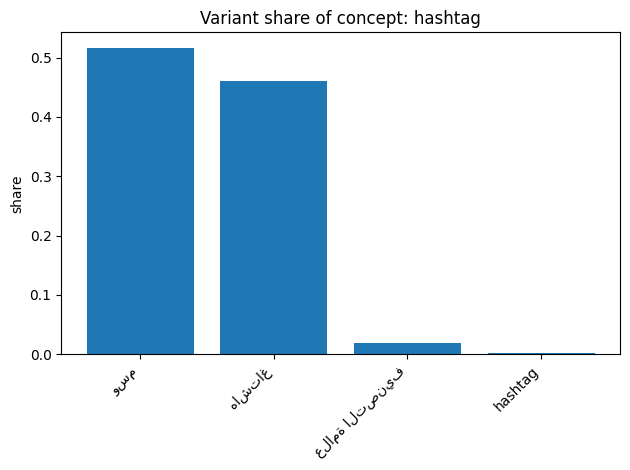

In [15]:
import matplotlib.pyplot as plt

concept = metrics_df["concept"].iloc[0]
plot_df = metrics_df[metrics_df["concept"] == concept].copy()

plt.figure()
plt.bar(plot_df["variant"], plot_df["share"])
plt.title(f"Variant share of concept: {concept}")
plt.xticks(rotation = 45, ha = "right")
plt.ylabel("share")
plt.tight_layout()
plt.show()